In [2]:
import numpy as np
import timeit
import pandas as pd
from typing import NamedTuple, List, Tuple
from IPython.display import display
from shapely.geometry import Point, Polygon
from shapely.geometry.polygon import Polygon as ShapelyPolygon
import sys
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML
# Add measurement mcts python package to path
sys.path.append('../src/measurement_mcts')
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment
from measurement_mcts.utils.utils import wrap_angle, min_max_normalize, rotate_about_point, angle_difference
from measurement_mcts.state_evaluation.hertg import HERTG

Toy Measurement Control Initialized


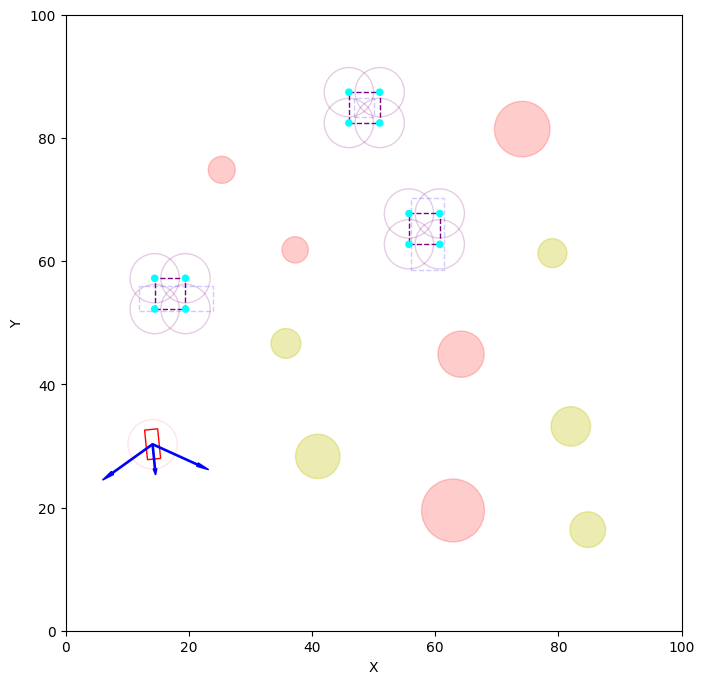

In [3]:
env = MeasurementControlEnvironment()
state = env.reset()
env.draw_state(state)

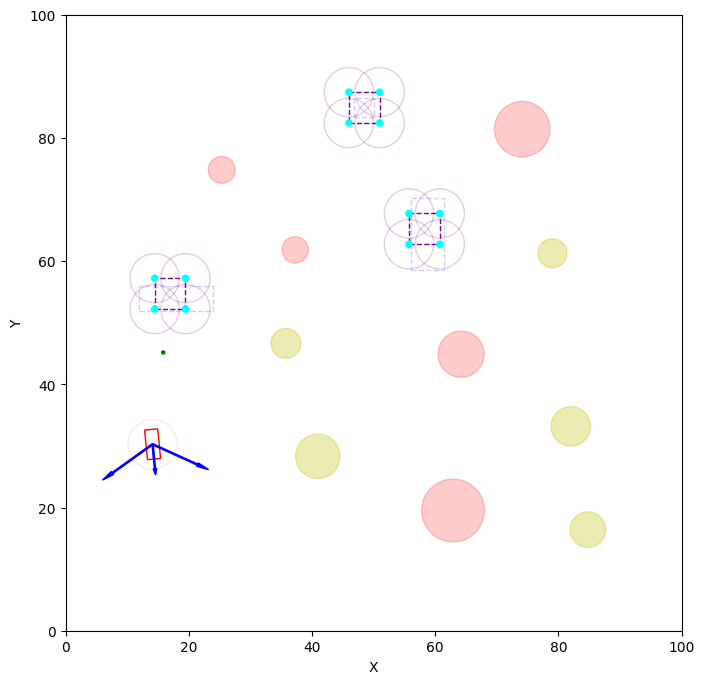

In [4]:
def get_hertg_target_point(state, env, dist_weight=0.1, bearing_weight=1, lookahead_distance=15, ooi_circle_space=4, ui=None):
    # Pull out state elements
    car_state, ooi_means, ooi_covs, horizon = state
    car_pos, car_yaw = car_state[:2], car_state[3]
    
    # Compute centers of each ooi and their range and bearing to the car
    ooi_centers = np.mean(ooi_means, axis=1)
    car_to_center_dists = np.linalg.norm(ooi_centers - car_pos, axis=1)
    car_to_center_bearings = np.abs(wrap_angle(np.arctan2(ooi_centers[:, 1] - car_pos[1], ooi_centers[:, 0] - car_pos[0]) - car_yaw))
    
    # Compute covariance trace sums for each ooi and normalize
    ooi_trace_sums = np.trace(ooi_covs, axis1=2, axis2=3)
    ooi_trace_sums[0] = [.4, .4, .4, .4]
    ooi_not_fully_observed = np.any(ooi_trace_sums > env.final_corner_cov_trace, axis=1).astype(int)

    # Mask off fully observed oois by giving them infinite cost
    ooi_mask = np.where(ooi_not_fully_observed == 0, np.inf, ooi_not_fully_observed)

    # Compute cost for each ooi and mask off fully observed oois
    ooi_cost = ooi_mask * (dist_weight * car_to_center_dists + bearing_weight * car_to_center_bearings)
    
    # Pick the lowest cost ooi as the best one
    best_ooi_idx = np.argmin(ooi_cost)
    
    # Project the target point from car to best ooi
    best_ooi_center = ooi_centers[best_ooi_idx]
    car_to_best_ooi = best_ooi_center - car_pos
    car_to_best_ooi_norm = np.linalg.norm(car_to_best_ooi)
    unit_car_to_best_ooi = car_to_best_ooi / car_to_best_ooi_norm
    
    # Cap the lookahead distance to the distance to the best ooi
    lookahead_distance = min(lookahead_distance, car_to_best_ooi_norm)
    target_point = car_pos + lookahead_distance * unit_car_to_best_ooi
    
    # Now to check for collision calculate the radius of each ooi and model as a circle
    ooi_radii = np.linalg.norm(ooi_means - ooi_centers[:, None], axis=2)
    ooi_max_radii = np.max(ooi_radii, axis=1)
    
    # Check if the target point is near an ooi circle
    target_point_near_ooi = np.linalg.norm(target_point - ooi_centers, axis=1) < ooi_max_radii + ooi_circle_space

    # Get indices where true
    near_ooi_indices = np.where(target_point_near_ooi)[0]
    
    # Angle to iterate with
    angle_iter = np.radians(5)
    
    if len(near_ooi_indices) > 1:
        raise ValueError('Multiple OOIs near target point')
    elif len(near_ooi_indices) == 1:
        print('Near OOI')
        # Pick direction to rotate around based on car heading relative to ooi
        car_to_close_ooi = ooi_centers[near_ooi_indices[0]] - car_pos
        car_to_ooi_angle = np.arctan2(car_to_close_ooi[1], car_to_close_ooi[0])
        angle_diff = angle_difference(car_to_ooi_angle, car_yaw)
        if angle_diff > 0:
            angle_direction = -1
        else:
            angle_direction = 1
        
        # First place the target_point on the ooi circle
        unit_car_to_close_ooi = car_to_close_ooi / np.linalg.norm(car_to_close_ooi)
        target_point = ooi_centers[near_ooi_indices[0]] + (ooi_circle_space + ooi_max_radii[near_ooi_indices[0]]) * -unit_car_to_close_ooi
        
        # Rotate target point around ooi circle until the distance from car to target point is greater than lookahead
        while np.linalg.norm(target_point - car_pos) < lookahead_distance:
            target_point = rotate_about_point(target_point, angle_direction * angle_iter, ooi_centers[near_ooi_indices[0]])
        
        if ui is not None:
            ui.draw_point(target_point, 'green', radius=0.25)
            
        return target_point
    
    # Now check if the target point is inside an obstacle/occlusion
    obs_means = np.vstack((env.object_manager.obstacle_means, env.object_manager.occlusion_means))
    obs_radii = np.hstack((env.object_manager.obstacle_radii, env.object_manager.occlusion_radii))
    target_point_to_obs_dists = np.linalg.norm(target_point - obs_means, axis=1)
    target_point_inside_obs = target_point_to_obs_dists < obs_radii + env.car_collision_radius
    collision_indices = np.where(target_point_inside_obs)[0]
    
    if len(collision_indices) > 1:
        raise ValueError('Multiple obstacles/occlusions near target point')
    elif len(collision_indices) == 1:
        print('Inside Obstacle/Occlusion')
        # Pick direction based on target_point heading relative to obstacle
        car_to_close_obs = obs_means[collision_indices[0]] - car_pos
        car_to_obs_angle = np.arctan2(car_to_close_obs[1], car_to_close_obs[0])
        car_to_target_point = target_point - car_pos
        car_to_target_point_angle = np.arctan2(car_to_target_point[1], car_to_target_point[0])
        angle_diff = angle_difference(car_to_obs_angle, car_to_target_point_angle)
        if angle_diff > 0:
            angle_direction = -1
        else:
            angle_direction = 1
        
        # First place the target_point on the obstacle circle
        unit_car_to_close_obs = car_to_close_obs / np.linalg.norm(car_to_close_obs)
        target_point = obs_means[collision_indices[0]] + (obs_radii[collision_indices[0]] + env.car_collision_radius) * -unit_car_to_close_obs
        
        # Rotate target point around ooi circle until the distance from car to target point is greater than lookahead
        while np.linalg.norm(target_point - car_pos) < lookahead_distance:
            target_point = rotate_about_point(target_point, angle_direction * angle_iter, obs_means[collision_indices[0]])
        
        if ui is not None:
            ui.draw_point(target_point, 'green', radius=0.25)
            
        return target_point

    if ui is not None:
        ui.draw_point(target_point, 'green', radius=0.25)
        
    return target_point

get_hertg_target_point(state, env, ui=env.ui)

env.draw_state(state)

In [5]:
def get_target_point_follow_action(car_state, env, target_point, no_turn_degrees=10, max_turn_degrees=20):
    car_pos = car_state[:2]
    car_yaw = car_state[3]
    steering_options = env.steering_acc_options[2:] # Take the 0 and positive options
    
    # Compute vector from car to target point
    car_to_target_point = target_point - car_pos
    car_to_target_point_angle = np.arctan2(car_to_target_point[1], car_to_target_point[0])
    
    # Compute angle difference between car heading and target point
    angle_diff = wrap_angle(car_to_target_point_angle - car_yaw)
    angle_sign = np.sign(angle_diff)
    
    # Determine action based on angle difference
    if np.abs(angle_diff) < np.radians(no_turn_degrees):
        return [1, steering_options[0]]                 # Accelerate, no turning
    elif np.abs(angle_diff) < np.radians(max_turn_degrees):
        return [1, angle_sign * steering_options[1]]    # Accelerate, turn slightly
    else:
        return [1, angle_sign * steering_options[2]]    # Accelerate, turn max
    
target_point = get_hertg_target_point(state, env)
get_target_point_follow_action(state[0], env, target_point)

[1, 1.0]

In [6]:
def animate(i):
    global state, observation, ax
    
    # Clear all existing patches from the axis
    for patch in ax.patches:
        patch.remove()
    print(f'Frame: {i}')
    env.draw_state(state, observation=observation, plot=False)
    target_point = get_hertg_target_point(state, env, ui=env.ui)
    action = get_target_point_follow_action(state[0], env, target_point)
    state, reward, done, observation = env.step(state, action, return_observation=True)
    
    ax.set_title(f'Frame: {i}\naction: {action}')
    
    # Add artists to the axis
    for artist in env.ui.get_artists():
        ax.add_patch(artist)
    
    return ax.patches
    
state = env.get_state()
observation = None


# Get the figure and axis from the UI
fig, ax = env.ui.plot(get_fig_ax=True)
plt.close()

ani = FuncAnimation(fig, animate, frames=20, interval=200, blit=False)
    
# Display the animation in the notebook
display(HTML(ani.to_jshtml()))

Frame: 0
Frame: 0
Frame: 1
Frame: 2
Frame: 3
Frame: 4
Frame: 5
Frame: 6
Frame: 7
Near OOI
Frame: 8
Near OOI
Frame: 9
Near OOI
Frame: 10
Near OOI
Frame: 11
Near OOI
Frame: 12
Near OOI
Frame: 13
Near OOI
Frame: 14
Near OOI
Frame: 15
Near OOI
Frame: 16
Near OOI
Frame: 17
Near OOI
Frame: 18
Near OOI
Frame: 19
Near OOI
